## Analysis of spatial factors

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import umap
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import scipy.io
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

import warnings
warnings.filterwarnings("ignore")

### Load results

In [2]:
res_path = "/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tutorials/new_examples/mouse_skin_repair"
adata = sc.read_h5ad(res_path + "/adata_inspire_mouse_skin_repair.h5ad")
basis_df = pd.read_csv(res_path + "/basis_df_inspire_mouse_skin_repair.csv", index_col=0)

### Visualization of gene signatures of factors

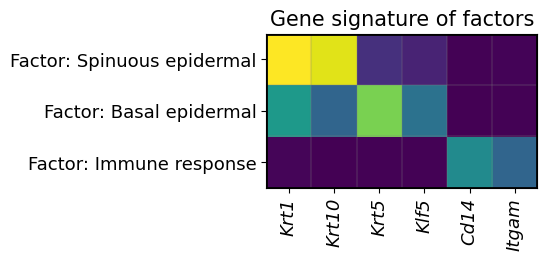

In [3]:
n_factors = 3
gene_set = ["Krt1", "Krt10",
            "Krt5","Klf5",
            "Cd14","Itgam"]
profile = basis_df.iloc[[9,7,6], :]
profile = profile[gene_set]
factor_names = ["Factor: Spinuous epidermal", "Factor: Basal epidermal", "Factor: Immune response"]

f = plt.figure(figsize=(3.5,2))
ax = f.add_subplot(111)
# ax.set_ylabel('Factor', fontsize=14)
im = ax.imshow(profile, cmap='viridis', interpolation='nearest', aspect='auto')
plt.yticks(np.arange(n_factors), factor_names, rotation=0, fontsize=13)
plt.xticks(np.arange(len(gene_set)), gene_set, rotation=90, fontsize=13, style="italic")
plt.title("Gene signature of factors", fontsize=15)
plt.vlines(x=np.arange(len(gene_set))-0.5, ymin=-0.5, ymax=n_factors-0.5, color="gray", linewidth=1.5, alpha=0.2)
plt.hlines(y=np.arange(n_factors)-0.5, xmin=-0.5, xmax=len(gene_set)-0.5, color="gray", linewidth=1.5, alpha=0.2)
plt.vlines(x=-0.5, ymin=-0.5, ymax=n_factors-0.5, color="k", linewidth=2, alpha=1)
plt.vlines(x=len(gene_set)-0.5, ymin=-0.5, ymax=n_factors-0.5, color="k", linewidth=2, alpha=1)
plt.hlines(y=-0.5, xmin=-0.5, xmax=len(gene_set)-0.5, color="k", linewidth=2, alpha=1)
plt.hlines(y=n_factors-0.5, xmin=-0.5, xmax=len(gene_set)-0.5, color="k", linewidth=2, alpha=1)

plt.show()

### Visualization of spatial distributions of factors and their top specific genes

In [4]:
data_dir = "/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/epithelial_organs/data/skin_pnas_tissue_repair"

adata = sc.read_h5ad(data_dir + "/adata_skin_repair_pod0.h5ad")
adata.var_names_make_unique()
adata.obs_names_make_unique()
adata.obs["pod"] = "pod 0"
adata.obs.index = adata.obs.index + "-0"
adata_1 = adata.copy()

adata = sc.read_h5ad(data_dir + "/adata_skin_repair_pod7.h5ad")
adata.var_names_make_unique()
adata.obs_names_make_unique()
adata.obs["pod"] = "pod 7"
adata.obs.index = adata.obs.index + "-1"
adata_2 = adata.copy()

adata_st_list = [adata_1, adata_2]
adata_1.obs.index = adata_1.obs.index + "-0"
adata_2.obs.index = adata_2.obs.index + "-1"
adata_raw = ad.concat(adata_st_list)
sc.pp.normalize_total(adata_raw, target_sum=1e4)
sc.pp.log1p(adata_raw)

In [5]:
res_path = "/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tutorials/new_examples/mouse_skin_repair"
adata_full = sc.read_h5ad(res_path + "/adata_inspire_mouse_skin_repair.h5ad")

adata_raw = adata_raw[adata_full.obs.index, :]
for g in ["Cd14","Itgam","Krt5","Klf5","Krt1","Krt10"]:
    adata_full.obs[g] = np.array(adata_raw[:, g].X).reshape(-1)


data_dir = "/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/epithelial_organs/data/skin_pnas_tissue_repair"

adata = sc.read_h5ad(data_dir + "/adata_skin_repair_pod0.h5ad")
adata.var_names_make_unique()
adata.obs_names_make_unique()
adata.obs["pod"] = "pod 0"
adata.obs.index = adata.obs.index + "-0-0"
adata_1 = adata.copy()

adata = sc.read_h5ad(data_dir + "/adata_skin_repair_pod7.h5ad")
adata.var_names_make_unique()
adata.obs_names_make_unique()
adata.obs["pod"] = "pod 7"
adata.obs.index = adata.obs.index + "-1-1"
adata_2 = adata.copy()


adata_1 = adata_1[adata_1.obs.index & adata_full.obs.index, :]
adata_2 = adata_2[adata_2.obs.index & adata_full.obs.index, :]

adata_1.obs["louvain"] = adata_full[adata_1.obs.index, :].obs["louvain"].values.astype(str)
adata_2.obs["louvain"] = adata_full[adata_2.obs.index, :].obs["louvain"].values.astype(str)

adata_1.obs["Proportion of spatial factor 10"] = adata_full[adata_1.obs.index, :].obs["Proportion of spatial factor 10"].values
adata_2.obs["Proportion of spatial factor 10"] = adata_full[adata_2.obs.index, :].obs["Proportion of spatial factor 10"].values

adata_1.obs["Proportion of spatial factor 8"] = adata_full[adata_1.obs.index, :].obs["Proportion of spatial factor 8"].values
adata_2.obs["Proportion of spatial factor 8"] = adata_full[adata_2.obs.index, :].obs["Proportion of spatial factor 8"].values

adata_1.obs["Proportion of spatial factor 7"] = adata_full[adata_1.obs.index, :].obs["Proportion of spatial factor 7"].values
adata_2.obs["Proportion of spatial factor 7"] = adata_full[adata_2.obs.index, :].obs["Proportion of spatial factor 7"].values

for g in ["Cd14","Itgam","Krt5","Klf5","Krt1","Krt10"]:
    adata_1.obs[g] = adata_full[adata_1.obs.index, :].obs[g].values
    adata_2.obs[g] = adata_full[adata_2.obs.index, :].obs[g].values

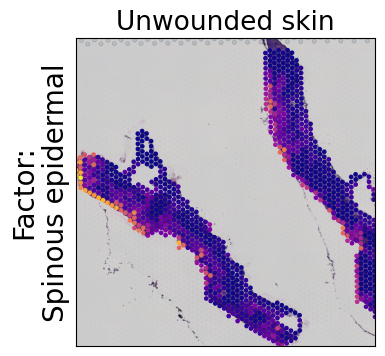

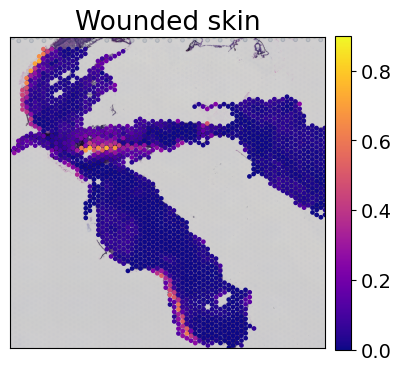

In [6]:
adata_st1 = adata_1
slice1_idx = "0"

fig = plt.figure(figsize=(4,4))
size = 5.5
# slice 1
ax0 = fig.add_subplot(1, 1, 1)
ax0.imshow(adata_st1.uns["spatial"][str(slice1_idx)]['images']['hires'])
ax0.set_aspect('equal')
x_coor = adata_st1.obsm["spatial"][:, 0] * adata_st1.uns["spatial"][str(slice1_idx)]['scalefactors']['tissue_hires_scalef']
y_coor = adata_st1.obsm["spatial"][:, 1] * adata_st1.uns["spatial"][str(slice1_idx)]['scalefactors']['tissue_hires_scalef']
ax0.scatter(x_coor, y_coor, s=size, rasterized=True, c=adata_st1.obs["Proportion of spatial factor 10"].values.reshape(-1), cmap="plasma",
            vmax=.9, vmin=0.0)
xmin, xmax = np.min(x_coor)-0, np.max(x_coor)+0
ymin, ymax = np.min(y_coor)-50, np.max(y_coor)
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymax, ymin)
ax0.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
ax0.set_title("Unwounded skin", fontsize=19)
ax0.set_ylabel("Factor:\nSpinous epidermal", fontsize=20)
plt.savefig("mouse_skin_repair_cluster_factor10_1.pdf", bbox_inches='tight', dpi=300)



adata_st2 = adata_2
slice2_idx = "0"

fig = plt.figure(figsize=(4.4,4.4))
size = 5.5
# slice 1
ax0 = fig.add_subplot(1, 1, 1)
ax0.imshow(adata_st2.uns["spatial"][str(slice1_idx)]['images']['hires'])
ax0.set_aspect('equal')
x_coor = adata_st2.obsm["spatial"][:, 0] * adata_st2.uns["spatial"][str(slice2_idx)]['scalefactors']['tissue_hires_scalef']
y_coor = adata_st2.obsm["spatial"][:, 1] * adata_st2.uns["spatial"][str(slice2_idx)]['scalefactors']['tissue_hires_scalef']
scatter0 = ax0.scatter(x_coor, y_coor, s=size, rasterized=True, c=adata_st2.obs["Proportion of spatial factor 10"].values.reshape(-1), cmap="plasma",
                       vmax=.9, vmin=0.0)
xmin, xmax = np.min(x_coor)-0, np.max(x_coor)+0
ymin, ymax = np.min(y_coor)-50, np.max(y_coor)
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymax, ymin)
ax0.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
ax0.set_title("Wounded skin", fontsize=19)
cbar = plt.colorbar(scatter0, ax=ax0, 
                    fraction=0.046, 
                    pad=0.03
                   )
cbar.ax.tick_params(labelsize=14)
plt.savefig("mouse_skin_repair_cluster_factor10_2.pdf", bbox_inches='tight', dpi=300)

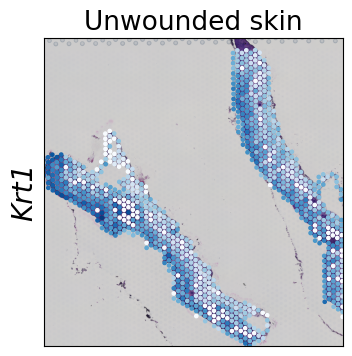

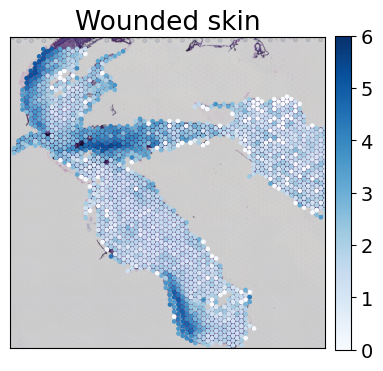

In [7]:
adata_st1 = adata_1
slice1_idx = "0"

fig = plt.figure(figsize=(4,4))
size = 5.5
# slice 1
ax0 = fig.add_subplot(1, 1, 1)
ax0.imshow(adata_st1.uns["spatial"][str(slice1_idx)]['images']['hires'])
ax0.set_aspect('equal')
x_coor = adata_st1.obsm["spatial"][:, 0] * adata_st1.uns["spatial"][str(slice1_idx)]['scalefactors']['tissue_hires_scalef']
y_coor = adata_st1.obsm["spatial"][:, 1] * adata_st1.uns["spatial"][str(slice1_idx)]['scalefactors']['tissue_hires_scalef']
ax0.scatter(x_coor, y_coor, s=size, rasterized=True, c=adata_st1.obs["Krt1"].values.reshape(-1), cmap="Blues", vmin=0., vmax=6)
xmin, xmax = np.min(x_coor)-0, np.max(x_coor)+0
ymin, ymax = np.min(y_coor)-50, np.max(y_coor)
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymax, ymin)
ax0.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
ax0.set_title("Unwounded skin", fontsize=19)
ax0.set_ylabel("Krt1", style="italic", fontsize=20)
plt.savefig("mouse_skin_repair_cluster_factor10_krt1_1.pdf", bbox_inches='tight', dpi=300)



adata_st2 = adata_2
slice2_idx = "0"

fig = plt.figure(figsize=(4.4,4.4))
size = 5.5
# slice 1
ax0 = fig.add_subplot(1, 1, 1)
ax0.imshow(adata_st2.uns["spatial"][str(slice1_idx)]['images']['hires'])
ax0.set_aspect('equal')
x_coor = adata_st2.obsm["spatial"][:, 0] * adata_st2.uns["spatial"][str(slice2_idx)]['scalefactors']['tissue_hires_scalef']
y_coor = adata_st2.obsm["spatial"][:, 1] * adata_st2.uns["spatial"][str(slice2_idx)]['scalefactors']['tissue_hires_scalef']
scatter0 = ax0.scatter(x_coor, y_coor, s=size, rasterized=True, c=adata_st2.obs["Krt1"].values.reshape(-1), cmap="Blues", vmin=0., vmax=6)
xmin, xmax = np.min(x_coor)-0, np.max(x_coor)+0
ymin, ymax = np.min(y_coor)-50, np.max(y_coor)
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymax, ymin)
ax0.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
ax0.set_title("Wounded skin", fontsize=19)
cbar = plt.colorbar(scatter0, ax=ax0, 
                    fraction=0.046, 
                    pad=0.03
                   )
cbar.ax.tick_params(labelsize=14)
plt.savefig("mouse_skin_repair_cluster_factor10_krt1_2.pdf", bbox_inches='tight', dpi=300)

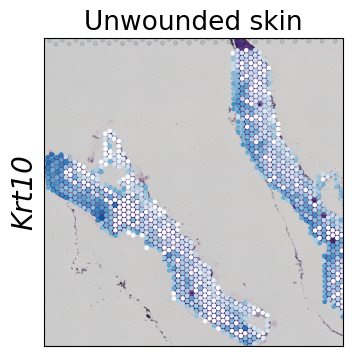

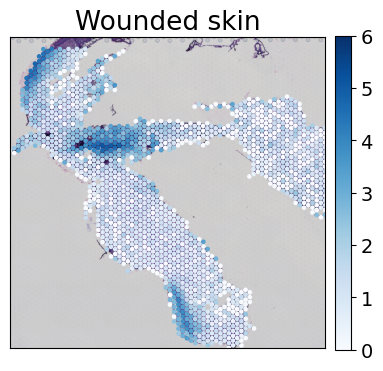

In [8]:
adata_st1 = adata_1
slice1_idx = "0"

fig = plt.figure(figsize=(4,4))
size = 5.5
# slice 1
ax0 = fig.add_subplot(1, 1, 1)
ax0.imshow(adata_st1.uns["spatial"][str(slice1_idx)]['images']['hires'])
ax0.set_aspect('equal')
x_coor = adata_st1.obsm["spatial"][:, 0] * adata_st1.uns["spatial"][str(slice1_idx)]['scalefactors']['tissue_hires_scalef']
y_coor = adata_st1.obsm["spatial"][:, 1] * adata_st1.uns["spatial"][str(slice1_idx)]['scalefactors']['tissue_hires_scalef']
ax0.scatter(x_coor, y_coor, s=size, rasterized=True, c=adata_st1.obs["Krt10"].values.reshape(-1), cmap="Blues", vmin=0., vmax=6)
xmin, xmax = np.min(x_coor)-0, np.max(x_coor)+0
ymin, ymax = np.min(y_coor)-50, np.max(y_coor)
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymax, ymin)
ax0.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
ax0.set_title("Unwounded skin", fontsize=19)
ax0.set_ylabel("Krt10", style="italic", fontsize=20)
plt.savefig("mouse_skin_repair_cluster_factor10_krt10_1.pdf", bbox_inches='tight', dpi=300)



adata_st2 = adata_2
slice2_idx = "0"

fig = plt.figure(figsize=(4.4,4.4))
size = 5.5
# slice 1
ax0 = fig.add_subplot(1, 1, 1)
ax0.imshow(adata_st2.uns["spatial"][str(slice1_idx)]['images']['hires'])
ax0.set_aspect('equal')
x_coor = adata_st2.obsm["spatial"][:, 0] * adata_st2.uns["spatial"][str(slice2_idx)]['scalefactors']['tissue_hires_scalef']
y_coor = adata_st2.obsm["spatial"][:, 1] * adata_st2.uns["spatial"][str(slice2_idx)]['scalefactors']['tissue_hires_scalef']
scatter0 = ax0.scatter(x_coor, y_coor, s=size, rasterized=True, c=adata_st2.obs["Krt10"].values.reshape(-1), cmap="Blues", vmin=0., vmax=6)
xmin, xmax = np.min(x_coor)-0, np.max(x_coor)+0
ymin, ymax = np.min(y_coor)-50, np.max(y_coor)
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymax, ymin)
ax0.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
ax0.set_title("Wounded skin", fontsize=19)
cbar = plt.colorbar(scatter0, ax=ax0, 
                    fraction=0.046, 
                    pad=0.03
                   )
cbar.ax.tick_params(labelsize=14)
plt.savefig("mouse_skin_repair_cluster_factor10_krt10_2.pdf", bbox_inches='tight', dpi=300)

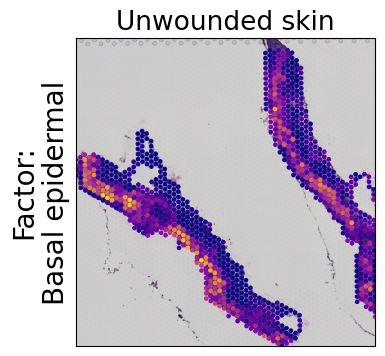

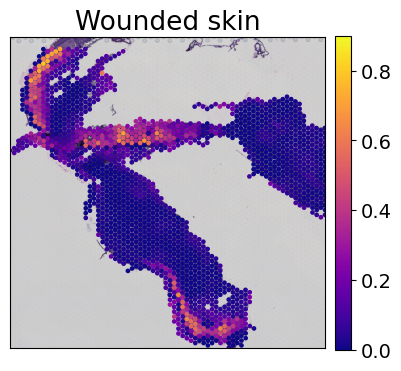

In [9]:
adata_st1 = adata_1
slice1_idx = "0"

fig = plt.figure(figsize=(4,4))
size = 5.5
# slice 1
ax0 = fig.add_subplot(1, 1, 1)
ax0.imshow(adata_st1.uns["spatial"][str(slice1_idx)]['images']['hires'])
ax0.set_aspect('equal')
x_coor = adata_st1.obsm["spatial"][:, 0] * adata_st1.uns["spatial"][str(slice1_idx)]['scalefactors']['tissue_hires_scalef']
y_coor = adata_st1.obsm["spatial"][:, 1] * adata_st1.uns["spatial"][str(slice1_idx)]['scalefactors']['tissue_hires_scalef']
ax0.scatter(x_coor, y_coor, s=size, rasterized=True, c=adata_st1.obs["Proportion of spatial factor 8"].values.reshape(-1), cmap="plasma",
            vmax=.9, vmin=0.0)
xmin, xmax = np.min(x_coor)-0, np.max(x_coor)+0
ymin, ymax = np.min(y_coor)-50, np.max(y_coor)
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymax, ymin)
ax0.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
ax0.set_title("Unwounded skin", fontsize=19)
ax0.set_ylabel("Factor:\nBasal epidermal", fontsize=20)
plt.savefig("mouse_skin_repair_cluster_factor8_1.pdf", bbox_inches='tight', dpi=300)



adata_st2 = adata_2
slice2_idx = "0"

fig = plt.figure(figsize=(4.4,4.4))
size = 5.5
# slice 1
ax0 = fig.add_subplot(1, 1, 1)
ax0.imshow(adata_st2.uns["spatial"][str(slice1_idx)]['images']['hires'])
ax0.set_aspect('equal')
x_coor = adata_st2.obsm["spatial"][:, 0] * adata_st2.uns["spatial"][str(slice2_idx)]['scalefactors']['tissue_hires_scalef']
y_coor = adata_st2.obsm["spatial"][:, 1] * adata_st2.uns["spatial"][str(slice2_idx)]['scalefactors']['tissue_hires_scalef']
scatter0 = ax0.scatter(x_coor, y_coor, s=size, rasterized=True, c=adata_st2.obs["Proportion of spatial factor 8"].values.reshape(-1), cmap="plasma",
                       vmax=.9, vmin=0.0)
xmin, xmax = np.min(x_coor)-0, np.max(x_coor)+0
ymin, ymax = np.min(y_coor)-50, np.max(y_coor)
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymax, ymin)
ax0.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
ax0.set_title("Wounded skin", fontsize=19)
cbar = plt.colorbar(scatter0, ax=ax0, 
                    fraction=0.046, 
                    pad=0.03
                   )
cbar.ax.tick_params(labelsize=14)
plt.savefig("mouse_skin_repair_cluster_factor8_2.pdf", bbox_inches='tight', dpi=300)

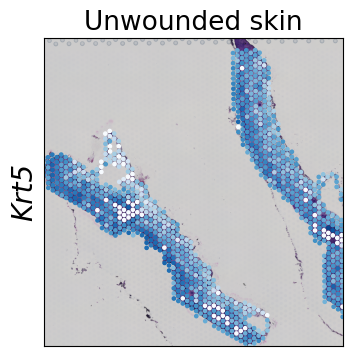

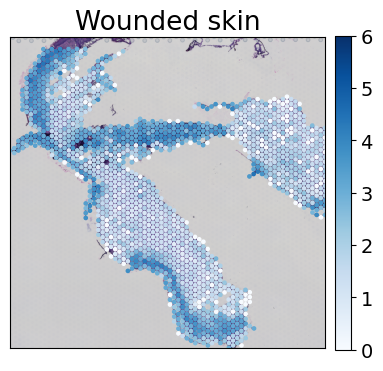

In [10]:
adata_st1 = adata_1
slice1_idx = "0"

fig = plt.figure(figsize=(4,4))
size = 5.5
# slice 1
ax0 = fig.add_subplot(1, 1, 1)
ax0.imshow(adata_st1.uns["spatial"][str(slice1_idx)]['images']['hires'])
ax0.set_aspect('equal')
x_coor = adata_st1.obsm["spatial"][:, 0] * adata_st1.uns["spatial"][str(slice1_idx)]['scalefactors']['tissue_hires_scalef']
y_coor = adata_st1.obsm["spatial"][:, 1] * adata_st1.uns["spatial"][str(slice1_idx)]['scalefactors']['tissue_hires_scalef']
ax0.scatter(x_coor, y_coor, s=size, rasterized=True, c=adata_st1.obs["Krt5"].values.reshape(-1), cmap="Blues", vmin=0., vmax=6)
xmin, xmax = np.min(x_coor)-0, np.max(x_coor)+0
ymin, ymax = np.min(y_coor)-50, np.max(y_coor)
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymax, ymin)
ax0.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
ax0.set_title("Unwounded skin", fontsize=19)
ax0.set_ylabel("Krt5", style="italic", fontsize=20)
plt.savefig("mouse_skin_repair_cluster_factor8_krt5_1.pdf", bbox_inches='tight', dpi=300)



adata_st2 = adata_2
slice2_idx = "0"

fig = plt.figure(figsize=(4.4,4.4))
size = 5.5
# slice 1
ax0 = fig.add_subplot(1, 1, 1)
ax0.imshow(adata_st2.uns["spatial"][str(slice1_idx)]['images']['hires'])
ax0.set_aspect('equal')
x_coor = adata_st2.obsm["spatial"][:, 0] * adata_st2.uns["spatial"][str(slice2_idx)]['scalefactors']['tissue_hires_scalef']
y_coor = adata_st2.obsm["spatial"][:, 1] * adata_st2.uns["spatial"][str(slice2_idx)]['scalefactors']['tissue_hires_scalef']
scatter0 = ax0.scatter(x_coor, y_coor, s=size, rasterized=True, c=adata_st2.obs["Krt5"].values.reshape(-1), cmap="Blues", vmin=0., vmax=6)
xmin, xmax = np.min(x_coor)-0, np.max(x_coor)+0
ymin, ymax = np.min(y_coor)-50, np.max(y_coor)
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymax, ymin)
ax0.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
ax0.set_title("Wounded skin", fontsize=19)
cbar = plt.colorbar(scatter0, ax=ax0, 
                    fraction=0.046, 
                    pad=0.03
                   )
cbar.ax.tick_params(labelsize=14)
plt.savefig("mouse_skin_repair_cluster_factor8_krt5_2.pdf", bbox_inches='tight', dpi=300)

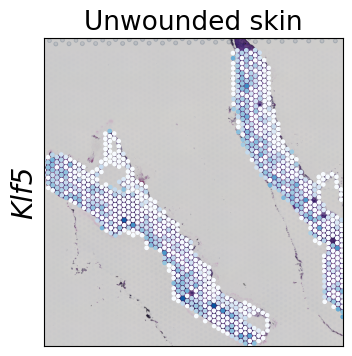

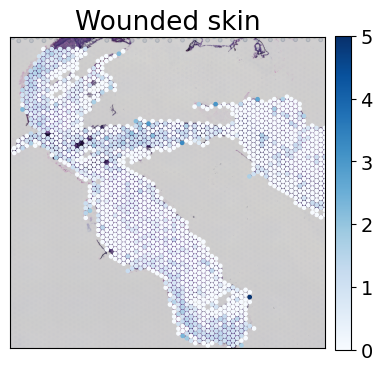

In [11]:
adata_st1 = adata_1
slice1_idx = "0"

fig = plt.figure(figsize=(4,4))
size = 5.5
# slice 1
ax0 = fig.add_subplot(1, 1, 1)
ax0.imshow(adata_st1.uns["spatial"][str(slice1_idx)]['images']['hires'])
ax0.set_aspect('equal')
x_coor = adata_st1.obsm["spatial"][:, 0] * adata_st1.uns["spatial"][str(slice1_idx)]['scalefactors']['tissue_hires_scalef']
y_coor = adata_st1.obsm["spatial"][:, 1] * adata_st1.uns["spatial"][str(slice1_idx)]['scalefactors']['tissue_hires_scalef']
ax0.scatter(x_coor, y_coor, s=size, rasterized=True, c=adata_st1.obs["Klf5"].values.reshape(-1), cmap="Blues", vmin=0., vmax=5)
xmin, xmax = np.min(x_coor)-0, np.max(x_coor)+0
ymin, ymax = np.min(y_coor)-50, np.max(y_coor)
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymax, ymin)
ax0.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
ax0.set_title("Unwounded skin", fontsize=19)
ax0.set_ylabel("Klf5", style="italic", fontsize=20)
plt.savefig("mouse_skin_repair_cluster_factor8_klf5_1.pdf", bbox_inches='tight', dpi=300)



adata_st2 = adata_2
slice2_idx = "0"

fig = plt.figure(figsize=(4.4,4.4))
size = 5.5
# slice 1
ax0 = fig.add_subplot(1, 1, 1)
ax0.imshow(adata_st2.uns["spatial"][str(slice1_idx)]['images']['hires'])
ax0.set_aspect('equal')
x_coor = adata_st2.obsm["spatial"][:, 0] * adata_st2.uns["spatial"][str(slice2_idx)]['scalefactors']['tissue_hires_scalef']
y_coor = adata_st2.obsm["spatial"][:, 1] * adata_st2.uns["spatial"][str(slice2_idx)]['scalefactors']['tissue_hires_scalef']
scatter0 = ax0.scatter(x_coor, y_coor, s=size, rasterized=True, c=adata_st2.obs["Klf5"].values.reshape(-1), cmap="Blues", vmin=0., vmax=5)
xmin, xmax = np.min(x_coor)-0, np.max(x_coor)+0
ymin, ymax = np.min(y_coor)-50, np.max(y_coor)
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymax, ymin)
ax0.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
ax0.set_title("Wounded skin", fontsize=19)
cbar = plt.colorbar(scatter0, ax=ax0, 
                    fraction=0.046, 
                    pad=0.03
                   )
cbar.ax.tick_params(labelsize=14)
plt.savefig("mouse_skin_repair_cluster_factor8_klf5_2.pdf", bbox_inches='tight', dpi=300)

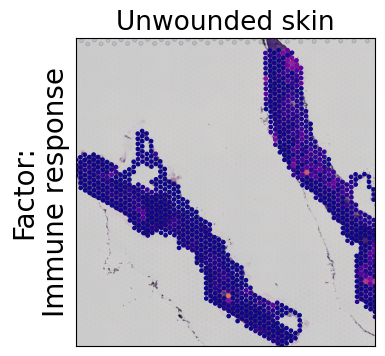

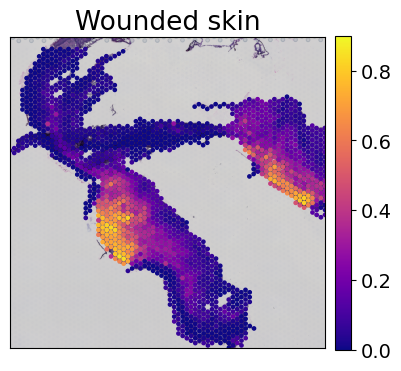

In [12]:
adata_st1 = adata_1
slice1_idx = "0"

fig = plt.figure(figsize=(4,4))
size = 5.5
# slice 1
ax0 = fig.add_subplot(1, 1, 1)
ax0.imshow(adata_st1.uns["spatial"][str(slice1_idx)]['images']['hires'])
ax0.set_aspect('equal')
x_coor = adata_st1.obsm["spatial"][:, 0] * adata_st1.uns["spatial"][str(slice1_idx)]['scalefactors']['tissue_hires_scalef']
y_coor = adata_st1.obsm["spatial"][:, 1] * adata_st1.uns["spatial"][str(slice1_idx)]['scalefactors']['tissue_hires_scalef']
ax0.scatter(x_coor, y_coor, s=size, rasterized=True, c=adata_st1.obs["Proportion of spatial factor 7"].values.reshape(-1), cmap="plasma",
            vmax=.9, vmin=0.0)
xmin, xmax = np.min(x_coor)-0, np.max(x_coor)+0
ymin, ymax = np.min(y_coor)-50, np.max(y_coor)
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymax, ymin)
ax0.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
ax0.set_title("Unwounded skin", fontsize=19)
ax0.set_ylabel("Factor:\nImmune response", fontsize=20)
plt.savefig("mouse_skin_repair_cluster_factor7_1.pdf", bbox_inches='tight', dpi=300)



adata_st2 = adata_2
slice2_idx = "0"

fig = plt.figure(figsize=(4.4,4.4))
size = 5.5
# slice 1
ax0 = fig.add_subplot(1, 1, 1)
ax0.imshow(adata_st2.uns["spatial"][str(slice1_idx)]['images']['hires'])
ax0.set_aspect('equal')
x_coor = adata_st2.obsm["spatial"][:, 0] * adata_st2.uns["spatial"][str(slice2_idx)]['scalefactors']['tissue_hires_scalef']
y_coor = adata_st2.obsm["spatial"][:, 1] * adata_st2.uns["spatial"][str(slice2_idx)]['scalefactors']['tissue_hires_scalef']
scatter0 = ax0.scatter(x_coor, y_coor, s=size, rasterized=True, c=adata_st2.obs["Proportion of spatial factor 7"].values.reshape(-1), cmap="plasma",
                       vmax=.9, vmin=0.0)
xmin, xmax = np.min(x_coor)-0, np.max(x_coor)+0
ymin, ymax = np.min(y_coor)-50, np.max(y_coor)
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymax, ymin)
ax0.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
ax0.set_title("Wounded skin", fontsize=19)
cbar = plt.colorbar(scatter0, ax=ax0, 
                    fraction=0.046, 
                    pad=0.03
                   )
cbar.ax.tick_params(labelsize=14)
plt.savefig("mouse_skin_repair_cluster_factor7_2.pdf", bbox_inches='tight', dpi=300)

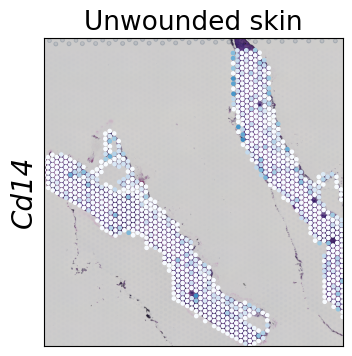

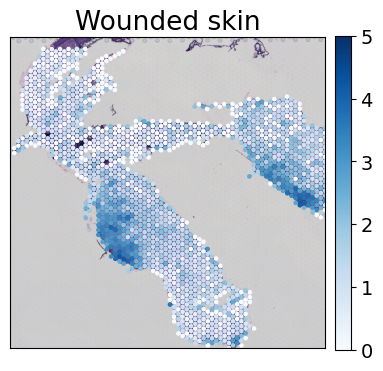

In [13]:
adata_st1 = adata_1
slice1_idx = "0"

fig = plt.figure(figsize=(4,4))
size = 5.5
# slice 1
ax0 = fig.add_subplot(1, 1, 1)
ax0.imshow(adata_st1.uns["spatial"][str(slice1_idx)]['images']['hires'])
ax0.set_aspect('equal')
x_coor = adata_st1.obsm["spatial"][:, 0] * adata_st1.uns["spatial"][str(slice1_idx)]['scalefactors']['tissue_hires_scalef']
y_coor = adata_st1.obsm["spatial"][:, 1] * adata_st1.uns["spatial"][str(slice1_idx)]['scalefactors']['tissue_hires_scalef']
ax0.scatter(x_coor, y_coor, s=size, rasterized=True, c=adata_st1.obs["Cd14"].values.reshape(-1), cmap="Blues", vmin=0., vmax=5)
xmin, xmax = np.min(x_coor)-0, np.max(x_coor)+0
ymin, ymax = np.min(y_coor)-50, np.max(y_coor)
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymax, ymin)
ax0.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
ax0.set_title("Unwounded skin", fontsize=19)
ax0.set_ylabel("Cd14", style="italic", fontsize=20)
plt.savefig("mouse_skin_repair_cluster_factor7_cd14_1.pdf", bbox_inches='tight', dpi=300)



adata_st2 = adata_2
slice2_idx = "0"

fig = plt.figure(figsize=(4.4,4.4))
size = 5.5
# slice 1
ax0 = fig.add_subplot(1, 1, 1)
ax0.imshow(adata_st2.uns["spatial"][str(slice1_idx)]['images']['hires'])
ax0.set_aspect('equal')
x_coor = adata_st2.obsm["spatial"][:, 0] * adata_st2.uns["spatial"][str(slice2_idx)]['scalefactors']['tissue_hires_scalef']
y_coor = adata_st2.obsm["spatial"][:, 1] * adata_st2.uns["spatial"][str(slice2_idx)]['scalefactors']['tissue_hires_scalef']
scatter0 = ax0.scatter(x_coor, y_coor, s=size, rasterized=True, c=adata_st2.obs["Cd14"].values.reshape(-1), cmap="Blues", vmin=0., vmax=5)
xmin, xmax = np.min(x_coor)-0, np.max(x_coor)+0
ymin, ymax = np.min(y_coor)-50, np.max(y_coor)
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymax, ymin)
ax0.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
ax0.set_title("Wounded skin", fontsize=19)
cbar = plt.colorbar(scatter0, ax=ax0, 
                    fraction=0.046, 
                    pad=0.03
                   )
cbar.ax.tick_params(labelsize=14)
plt.savefig("mouse_skin_repair_cluster_factor7_cd14_2.pdf", bbox_inches='tight', dpi=300)

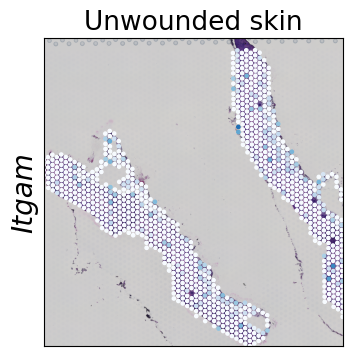

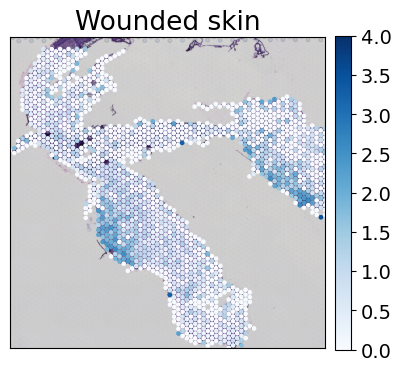

In [14]:
adata_st1 = adata_1
slice1_idx = "0"

fig = plt.figure(figsize=(4,4))
size = 5.5
# slice 1
ax0 = fig.add_subplot(1, 1, 1)
ax0.imshow(adata_st1.uns["spatial"][str(slice1_idx)]['images']['hires'])
ax0.set_aspect('equal')
x_coor = adata_st1.obsm["spatial"][:, 0] * adata_st1.uns["spatial"][str(slice1_idx)]['scalefactors']['tissue_hires_scalef']
y_coor = adata_st1.obsm["spatial"][:, 1] * adata_st1.uns["spatial"][str(slice1_idx)]['scalefactors']['tissue_hires_scalef']
ax0.scatter(x_coor, y_coor, s=size, rasterized=True, c=adata_st1.obs["Itgam"].values.reshape(-1), cmap="Blues", vmin=0., vmax=4)
xmin, xmax = np.min(x_coor)-0, np.max(x_coor)+0
ymin, ymax = np.min(y_coor)-50, np.max(y_coor)
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymax, ymin)
ax0.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
ax0.set_title("Unwounded skin", fontsize=19)
ax0.set_ylabel("Itgam", style="italic", fontsize=20)
plt.savefig("mouse_skin_repair_cluster_factor7_itgam_1.pdf", bbox_inches='tight', dpi=300)



adata_st2 = adata_2
slice2_idx = "0"

fig = plt.figure(figsize=(4.4,4.4))
size = 5.5
# slice 1
ax0 = fig.add_subplot(1, 1, 1)
ax0.imshow(adata_st2.uns["spatial"][str(slice1_idx)]['images']['hires'])
ax0.set_aspect('equal')
x_coor = adata_st2.obsm["spatial"][:, 0] * adata_st2.uns["spatial"][str(slice2_idx)]['scalefactors']['tissue_hires_scalef']
y_coor = adata_st2.obsm["spatial"][:, 1] * adata_st2.uns["spatial"][str(slice2_idx)]['scalefactors']['tissue_hires_scalef']
scatter0 = ax0.scatter(x_coor, y_coor, s=size, rasterized=True, c=adata_st2.obs["Itgam"].values.reshape(-1), cmap="Blues", vmin=0., vmax=4)
xmin, xmax = np.min(x_coor)-0, np.max(x_coor)+0
ymin, ymax = np.min(y_coor)-50, np.max(y_coor)
ax0.set_xlim(xmin, xmax)
ax0.set_ylim(ymax, ymin)
ax0.tick_params(axis='both',bottom=False, top=False, left=False, right=False, labelleft=False, labelbottom=False, grid_alpha=0)
ax0.set_title("Wounded skin", fontsize=19)
cbar = plt.colorbar(scatter0, ax=ax0, 
                    fraction=0.046, 
                    pad=0.03
                   )
cbar.ax.tick_params(labelsize=14)
plt.savefig("mouse_skin_repair_cluster_factor7_itgam_2.pdf", bbox_inches='tight', dpi=300)